<a href="https://colab.research.google.com/github/SourStone/Portafolio-Projectos-Programacion/blob/main/DemoCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.normalization import batch_normalization


In [ ]:
import PIL
import PIL.Image
import tensorflow_datasets as tfds
from tensorflow.keras import layers
import pathlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


acceso al el drive

In [ ]:
!ls "/content/drive/My Drive/Colab Notebooks"

"Comparto 'Plantilla_Encuentro_2022_Ricardo' contigo"
'Copy of prototipo2_semillero.ipynb'
 defect_mnist.h5
 DemoCNN.ipynb
 LeatherDefectClassification
 Plantilla_Encuentro_2022_Ricardo.pptx
 Practica_1.ipynb
 Practica_1_succesfull.ipynb
 prototipo1_semillero.ipynb
 prototipo2_semillero.ipynb
 sportimages.zip
'sportimages.zip (Unzipped Files)'
 Untitled0.ipynb
 Untitled1.ipynb


In [ ]:
batch_size = 1
img_height = 227
img_width = 227

crear dataset diminuto para demostracion

In [ ]:
data_dir = os.path.join(os.getcwd(), 'drive/My Drive/Colab Notebooks/LeatherDefectClassification')
demo_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.9,
    subset = "training",
    seed = 123,
    image_size=(img_height, img_width),
    batch_size = batch_size
)

Found 3600 files belonging to 6 classes.
Using 360 files for training.


In [ ]:
class_names = demo_ds.class_names

acceso a modelo ya compilado

In [ ]:
demo_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/defect_mnist.h5')

testeo de prediccion

In [ ]:
predictions = demo_model.predict(demo_ds)

360/360 [==============================] - 35s 95ms/step


In [ ]:
score = tf.nn.softmax(predictions[0])

print(
    "esta imagen tiene mayor probabilidad de ser {} con un porcentaje de {:.2f}% de seguridad"
    .format(class_names[np.argmax(score)], 100*np.max(score))
)

esta imagen tiene mayor probabilidad de ser loose grains con un porcentaje de 99.91% de seguridad


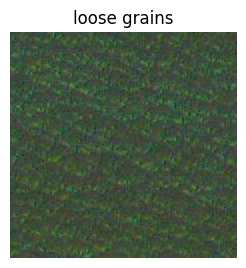

In [ ]:
plt.figure(figsize=(10,10))
for images, labels in demo_ds.take(1):
  for i in range(1):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
